In [1]:
# ==============================
# Import Required Libraries
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy.stats import zscore

In [2]:
# ==============================
# Load Healthcare Dataset
# ==============================


data = pd.read_csv(r"C:\Users\HP\Downloads\healthcare_dataset.csv")

data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,NaN,NaN,NaN,NaN,118.00,NaN,NaN,0
1,2,69.0,Male,South,22.91,136.29,263.40,106.29,1
2,3,NaN,NaN,NaN,NaN,88.49,NaN,NaN,0
3,4,32.0,Male,South,29.01,164.07,170.98,74.69,1
4,5,60.0,Male,South,25.26,106.93,155.68,66.40,1


In [3]:
# ==============================
# Introduce Missing Values
# ==============================

for col in ['age', 'gender', 'region', 'bmi', 'cholesterol', 'glucose']:

    data.loc[data.sample(frac=0.1).index, col] = np.nan

data.isnull().sum()

patient_id         0
age               96
gender            96
region            98
bmi               89
blood_pressure     0
cholesterol       97
glucose           96
disease_risk       0
dtype: int64

In [4]:
# ==============================
# Introduce Outliers
# ==============================

outlier_index = np.random.choice(data.index, 20)

data.loc[outlier_index, 'bmi'] = data['bmi'] * 2

data.loc[outlier_index, 'blood_pressure'] = data['blood_pressure'] * 1.8

data.loc[outlier_index, 'cholesterol'] = data['cholesterol'] * 2

data.loc[outlier_index, 'glucose'] = data['glucose'] * 2

In [5]:
# Dataset Shape

print("Dataset Shape :", data.shape)

# Dataset Info

data.info()

Dataset Shape : (500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      500 non-null    int64  
 1   age             404 non-null    float64
 2   gender          404 non-null    object 
 3   region          402 non-null    object 
 4   bmi             411 non-null    float64
 5   blood_pressure  500 non-null    float64
 6   cholesterol     403 non-null    float64
 7   glucose         404 non-null    float64
 8   disease_risk    500 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 35.3+ KB


In [6]:
# ==============================
# Missing Value Percentage
# ==============================

missing = data.isnull().sum()

missing_percent = (missing / len(data)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

missing_report

,Missing Values,Percentage
patient_id,0,0.0
age,96,19.2
gender,96,19.2
region,98,19.6
bmi,89,17.8
blood_pressure,0,0.0
cholesterol,97,19.4
glucose,96,19.2
disease_risk,0,0.0


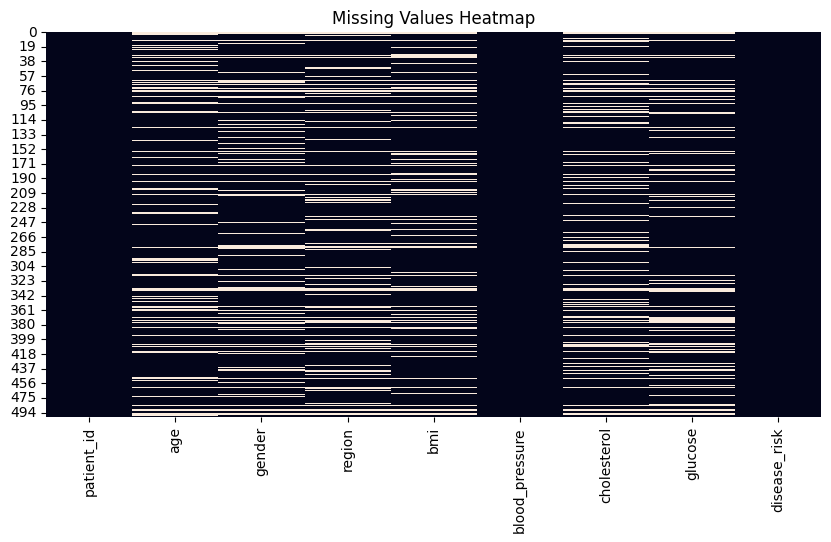

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(data.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [8]:
# ==============================
# Numerical Imputation
# ==============================

num_cols = ['age', 'bmi', 'cholesterol', 'glucose']

num_imputer = SimpleImputer(strategy='mean')

data[num_cols] = num_imputer.fit_transform(data[num_cols])

data[num_cols].isnull().sum()

age            0
bmi            0
cholesterol    0
glucose        0
dtype: int64

In [9]:
# ==============================
# Categorical Imputation
# ==============================

cat_cols = ['gender', 'region']

cat_imputer = SimpleImputer(strategy='most_frequent')

data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

data[cat_cols].isnull().sum()

gender    0
region    0
dtype: int64

In [10]:
# ==============================
# Missing Indicator
# ==============================

data['bmi_missing'] = data['bmi'].isnull().astype(int)

# Random Sample Imputation

random_sample = data['bmi'].dropna().sample(
    data['bmi'].isnull().sum(),
    random_state=42
)

random_sample.index = data[data['bmi'].isnull()].index

data.loc[data['bmi'].isnull(), 'bmi'] = random_sample

In [11]:
# ==============================
# KNN Imputation
# ==============================

knn_data = data.copy()

knn_cols = ['age', 'bmi', 'blood_pressure',
            'cholesterol', 'glucose']

knn_imputer = KNNImputer(n_neighbors=5)

knn_data[knn_cols] = knn_imputer.fit_transform(knn_data[knn_cols])

knn_data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_missing
0,1,50.299505,Female,South,29.027397,118.00,213.951886,117.437624,0,0
1,2,69.000000,Female,South,22.910000,136.29,263.400000,106.290000,1,0
2,3,50.299505,Female,South,29.027397,88.49,213.951886,117.437624,0,0
3,4,50.299505,Male,South,29.010000,164.07,170.980000,74.690000,1,0
4,5,60.000000,Male,South,25.260000,106.93,155.680000,66.400000,1,0


In [12]:
# ==============================
# MICE Imputation
# ==============================

mice_data = data.copy()

mice_cols = ['age', 'bmi', 'blood_pressure',
             'cholesterol', 'glucose']

mice_imputer = IterativeImputer(random_state=42)

mice_data[mice_cols] = mice_imputer.fit_transform(mice_data[mice_cols])

mice_data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_missing
0,1,50.299505,Female,South,29.027397,118.00,213.951886,117.437624,0,0
1,2,69.000000,Female,South,22.910000,136.29,263.400000,106.290000,1,0
2,3,50.299505,Female,South,29.027397,88.49,213.951886,117.437624,0,0
3,4,50.299505,Male,South,29.010000,164.07,170.980000,74.690000,1,0
4,5,60.000000,Male,South,25.260000,106.93,155.680000,66.400000,1,0


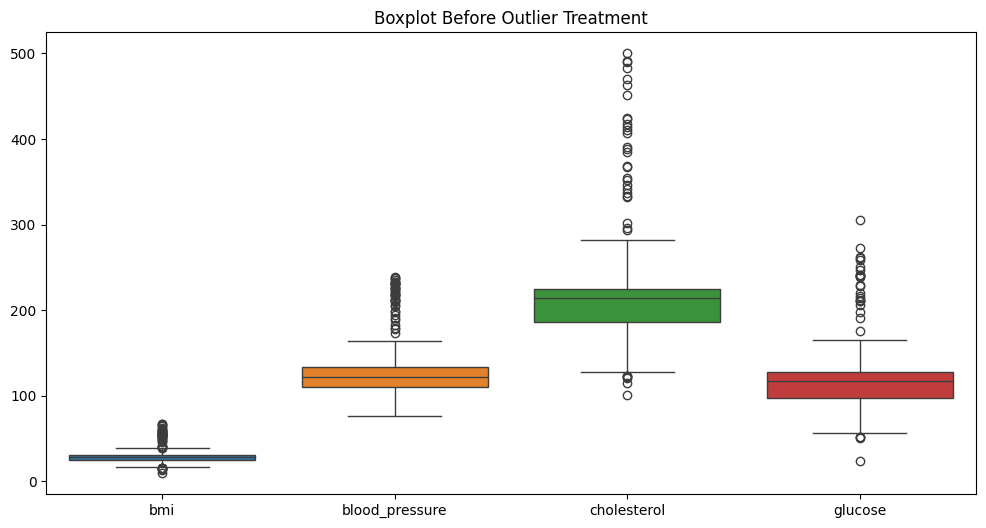

In [13]:
# Boxplot Before Treatment

plt.figure(figsize=(12,6))

sns.boxplot(data=data[['bmi',
                       'blood_pressure',
                       'cholesterol',
                       'glucose']])

plt.title("Boxplot Before Outlier Treatment")

plt.show()

In [14]:
# ==============================
# Z-Score Method
# ==============================

z_scores = np.abs(zscore(
    data[['bmi',
          'blood_pressure',
          'cholesterol',
          'glucose']]
))

threshold = 3

zscore_data = data[(z_scores < threshold).all(axis=1)]

print("Original Shape :", data.shape)

print("After Z-score :", zscore_data.shape)

Original Shape : (500, 10)
After Z-score : (464, 10)


In [15]:
# ==============================
# IQR Method
# ==============================

iqr_data = data.copy()

Q1 = iqr_data[['bmi',
               'blood_pressure',
               'cholesterol',
               'glucose']].quantile(0.25)

Q3 = iqr_data[['bmi',
               'blood_pressure',
               'cholesterol',
               'glucose']].quantile(0.75)

IQR = Q3 - Q1

iqr_data = iqr_data[
    ~((iqr_data[['bmi',
                  'blood_pressure',
                  'cholesterol',
                  'glucose']] < (Q1 - 1.5 * IQR)) |

      (iqr_data[['bmi',
                  'blood_pressure',
                  'cholesterol',
                  'glucose']] > (Q3 + 1.5 * IQR))
     ).any(axis=1)
]

print("Original Shape :", data.shape)

print("After IQR :", iqr_data.shape)

Original Shape : (500, 10)
After IQR : (434, 10)


In [16]:
# ==============================
# Percentile Method
# ==============================

percentile_data = data.copy()

for col in ['bmi',
            'blood_pressure',
            'cholesterol',
            'glucose']:

    lower = percentile_data[col].quantile(0.01)

    upper = percentile_data[col].quantile(0.99)

    percentile_data[col] = np.where(
        percentile_data[col] < lower,
        lower,
        percentile_data[col]
    )

    percentile_data[col] = np.where(
        percentile_data[col] > upper,
        upper,
        percentile_data[col]
    )

percentile_data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_missing
0,1,50.299505,Female,South,29.027397,118.00,213.951886,117.437624,0,0
1,2,69.000000,Female,South,22.910000,136.29,263.400000,106.290000,1,0
2,3,50.299505,Female,South,29.027397,88.49,213.951886,117.437624,0,0
3,4,50.299505,Male,South,29.010000,164.07,170.980000,74.690000,1,0
4,5,60.000000,Male,South,25.260000,106.93,155.680000,66.400000,1,0


In [17]:
# ==============================
# Winsorization
# ==============================

winsor_data = data.copy()

for col in ['bmi',
            'blood_pressure',
            'cholesterol',
            'glucose']:

    lower = winsor_data[col].quantile(0.05)

    upper = winsor_data[col].quantile(0.95)

    winsor_data[col] = np.clip(
        winsor_data[col],
        lower,
        upper
    )

winsor_data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_missing
0,1,50.299505,Female,South,29.027397,118.0000,213.951886,117.437624,0,0
1,2,69.000000,Female,South,22.910000,136.2900,263.400000,106.290000,1,0
2,3,50.299505,Female,South,29.027397,96.0085,213.951886,117.437624,0,0
3,4,50.299505,Male,South,29.010000,164.0700,170.980000,74.690000,1,0
4,5,60.000000,Male,South,25.260000,106.9300,155.680000,71.808500,1,0


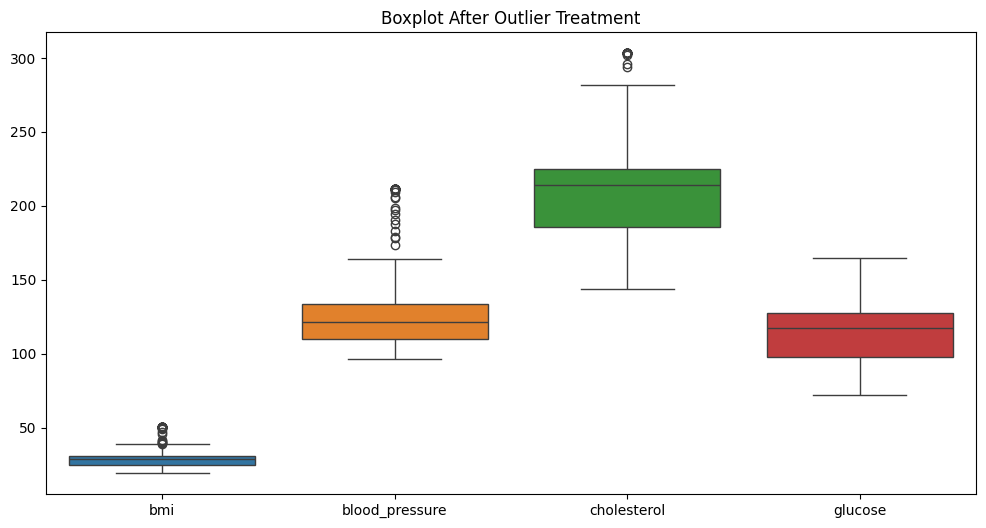

In [18]:
# ==============================
# Boxplot After Treatment
# ==============================

plt.figure(figsize=(12,6))

sns.boxplot(data=winsor_data[['bmi',
                              'blood_pressure',
                              'cholesterol',
                              'glucose']])

plt.title("Boxplot After Outlier Treatment")

plt.show()

In [19]:
# ==============================
# Final Clean Dataset
# ==============================

final_data = winsor_data.copy()

final_data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_missing
0,1,50.299505,Female,South,29.027397,118.0000,213.951886,117.437624,0,0
1,2,69.000000,Female,South,22.910000,136.2900,263.400000,106.290000,1,0
2,3,50.299505,Female,South,29.027397,96.0085,213.951886,117.437624,0,0
3,4,50.299505,Male,South,29.010000,164.0700,170.980000,74.690000,1,0
4,5,60.000000,Male,South,25.260000,106.9300,155.680000,71.808500,1,0
